In [2]:
# Шаг 1: импорт всего и вся
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Шаг 2: загрузка
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print(f"Размер обучающей выборки: {train_data.shape}")
print(f"Размер тестовой выборки: {test_data.shape}")

train_data.head()

Размер обучающей выборки: (891, 12)
Размер тестовой выборки: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Шаг 3: инфо
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass  

In [5]:
# Шаг 4: смотрим пропуски
missing_train = train_data.isnull().sum()
missing_percent_train = (missing_train / len(train_data)) * 100
missing_df_train = pd.DataFrame({
    'Пропущенные значения': missing_train,
    'Процент, %': missing_percent_train
})
print("Пропущенные значения в обучающей выборке:")
print(missing_df_train[missing_df_train['Пропущенные значения'] > 0])

missing_test = test_data.isnull().sum()
missing_percent_test = (missing_test / len(test_data)) * 100
missing_df_test = pd.DataFrame({
    'Пропущенные значения': missing_test,
    'Процент, %': missing_percent_test
})
print("Пропущенные значения в тестовой выборке:")
print(missing_df_test[missing_df_test['Пропущенные значения'] > 0])

Пропущенные значения в обучающей выборке:
          Пропущенные значения  Процент, %
Age                        177   19.865320
Cabin                      687   77.104377
Embarked                     2    0.224467
Пропущенные значения в тестовой выборке:
       Пропущенные значения  Процент, %
Age                      86   20.574163
Fare                      1    0.239234
Cabin                   327   78.229665


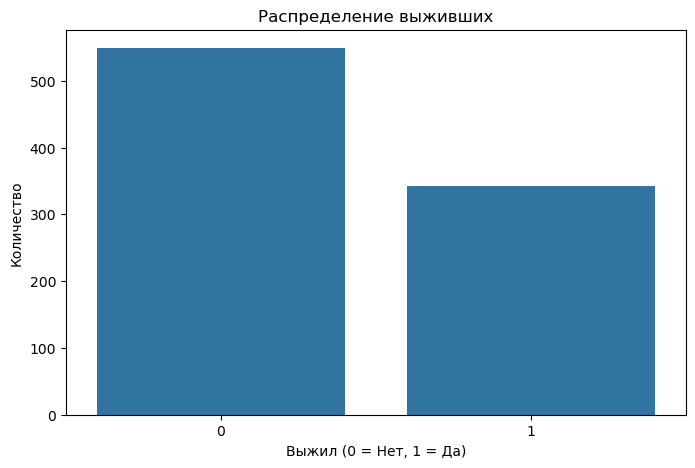

Процент выживших: 38.38%
Процент погибших: 61.62%


In [6]:
# шаг 5: смотрим данные по выжившим и погибшим
# Кол-во
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=train_data)
plt.title('Распределение выживших')
plt.xlabel('Выжил (0 = Нет, 1 = Да)')
plt.ylabel('Количество')
plt.show()

# Процент
survival_rate = train_data['Survived'].value_counts(normalize=True) * 100
print(f"Процент выживших: {survival_rate[1]:.2f}%")
print(f"Процент погибших: {survival_rate[0]:.2f}%")

In [7]:
# Шаг 6: обработка пропусков
train_data_clean = train_data.copy()
test_data_clean = test_data.copy()

# Заполняем пропуски возраста медианой
age_median_train = train_data_clean['Age'].median()
age_median_test = test_data_clean['Age'].median()
train_data_clean['Age'].fillna(age_median_train, inplace=True)
test_data_clean['Age'].fillna(age_median_test, inplace=True)

# Заполняем пропуски порта посадки модой
embarked_mode = train_data_clean['Embarked'].mode()[0]
train_data_clean['Embarked'].fillna(embarked_mode, inplace=True)

# Заполняем пропуски цены билета в тестовых данных медианой
fare_median_test = test_data_clean['Fare'].median()
test_data_clean['Fare'].fillna(fare_median_test, inplace=True)

# Удаляем столбец Cabin
train_data_clean.drop('Cabin', axis=1, inplace=True)
test_data_clean.drop('Cabin', axis=1, inplace=True)

print("Пропущенные значения после обработки:")
print("Обучающая выборка:")
print(train_data_clean.isnull().sum().sum())
print("Тестовая выборка:")
print(test_data_clean.isnull().sum().sum())

Пропущенные значения после обработки:
Обучающая выборка:
0
Тестовая выборка:
0


In [8]:
# Шаг 7: новые признаки
# Признак: размер семьи
train_data_clean['FamilySize'] = train_data_clean['SibSp'] + train_data_clean['Parch'] + 1
test_data_clean['FamilySize'] = test_data_clean['SibSp'] + test_data_clean['Parch'] + 1

# Признак: одинокий пассажир
train_data_clean['IsAlone'] = (train_data_clean['FamilySize'] == 1).astype(int)
test_data_clean['IsAlone'] = (test_data_clean['FamilySize'] == 1).astype(int)

# Смотрим титулы
for dataset in [train_data_clean, test_data_clean]:
    dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Lady': 'Rare', 'Sir': 'Rare',
    'Mme': 'Mrs', 'Countess': 'Rare', 'Capt': 'Rare', 'Jonkheer': 'Rare',
    'Don': 'Rare', 'Dona': 'Rare'
}

for dataset in [train_data_clean, test_data_clean]:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'].fillna('Mr', inplace=True)  # Заполняем оставшиеся пропуски

print("Уникальные титулы после обработки:")
print(train_data_clean['Title'].value_counts())

Уникальные титулы после обработки:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [9]:
# Шаг 8: кодируем категориальные признаки
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_features = ['Sex', 'Embarked', 'Title']
for feature in categorical_features:
    le = LabelEncoder()
    # Объединяем обучающие и тестовые данные для консистентного кодирования
    combined = pd.concat([train_data_clean[feature], test_data_clean[feature]], axis=0)
    le.fit(combined)
    
    # Преобразуем признаки
    train_data_clean[feature] = le.transform(train_data_clean[feature])
    test_data_clean[feature] = le.transform(test_data_clean[feature])
    label_encoders[feature] = le

print("Категориальные признаки закодированы")

Категориальные признаки закодированы


In [10]:
# Шаг 9: выбираем признаки
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 
            'FamilySize', 'IsAlone', 'Title']

# Признаки и целевая переменная
X_train = train_data_clean[features]
y_train = train_data_clean['Survived']
X_test = test_data_clean[features]

print(f"Размер X_train: {X_train.shape}")
print(f"Размер y_train: {y_train.shape}")
print(f"Размер X_test: {X_test.shape}")

Размер X_train: (891, 10)
Размер y_train: (891,)
Размер X_test: (418, 10)


In [11]:
# Шаг 10: масштабирование
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Признаки масштабированы")

Признаки масштабированы


In [12]:
# Шаг 11: разделяем данные на обучающую и валидационную выборки
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Размер X_train_split: {X_train_split.shape}")
print(f"Размер X_val: {X_val.shape}")
print(f"Размер y_train_split: {y_train_split.shape}")
print(f"Размер y_val: {y_val.shape}")

Размер X_train_split: (712, 10)
Размер X_val: (179, 10)
Размер y_train_split: (712,)
Размер y_val: (179,)


In [13]:
# Шаг 12: обучаем модель через лес
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(
    n_estimators=100,  # количество деревьев
    max_depth=5,       # максимальная глубина деревьев
    random_state=42    # для воспроизводимости
)

model.fit(X_train_split, y_train_split)

# Предсказания 
y_val_pred = model.predict(X_val)

# Оценка 
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Точность на валидационной выборке: {val_accuracy:.4f}")
print("\nОтчет по классификации:")
print(classification_report(y_val, y_val_pred))

Точность на валидационной выборке: 0.8212

Отчет по классификации:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.84      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.83      0.79      0.80       179
weighted avg       0.82      0.82      0.82       179



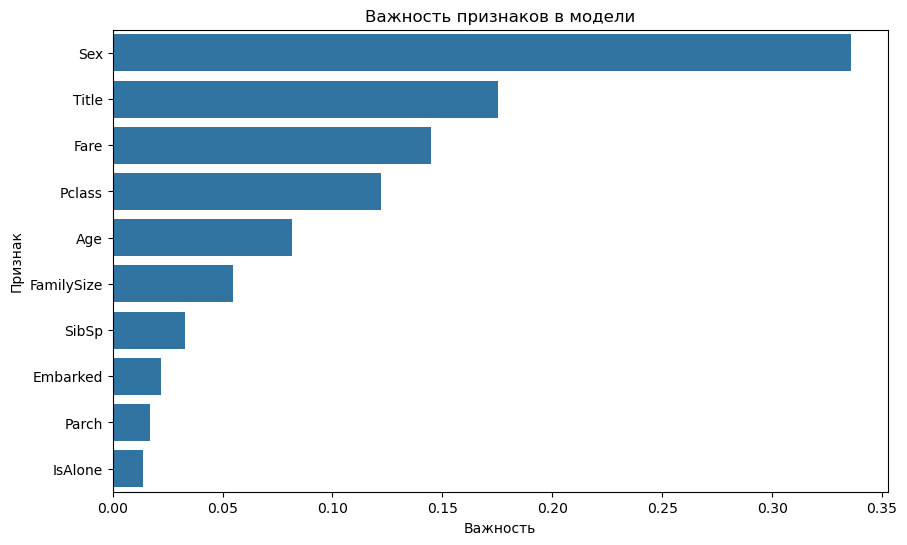

Важность признаков:
      Признак  Важность
1         Sex  0.335744
9       Title  0.175306
5        Fare  0.144641
0      Pclass  0.122032
2         Age  0.081468
7  FamilySize  0.054626
3       SibSp  0.033030
6    Embarked  0.021966
4       Parch  0.017175
8     IsAlone  0.014012


In [14]:
# Шаг 13: смотрим важность признаков
feature_importance = pd.DataFrame({
    'Признак': features,
    'Важность': model.feature_importances_
}).sort_values('Важность', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Важность', y='Признак', data=feature_importance)
plt.title('Важность признаков в модели')
plt.show()

print("Важность признаков:")
print(feature_importance)

In [15]:
# Шаг 14: делаем предсказание
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(f"Количество предсказаний: {len(predictions)}")
print(f"Количество выживших в тестовых данных: {sum(predictions)}")
print(f"Процент выживших в тестовых данных: {(sum(predictions)/len(predictions))*100:.2f}%")

Количество предсказаний: 418
Количество выживших в тестовых данных: 161
Процент выживших в тестовых данных: 38.52%


In [16]:
# Шаг 15: сохраняем
output = pd.DataFrame({
    'PassengerId': test_data.PassengerId,
    'Survived': predictions
})

# Сохраняем в CSV файл
output.to_csv('submission.csv', index=False)

print("Файл submission.csv сохранен")
print(output.head())

Файл submission.csv сохранен
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


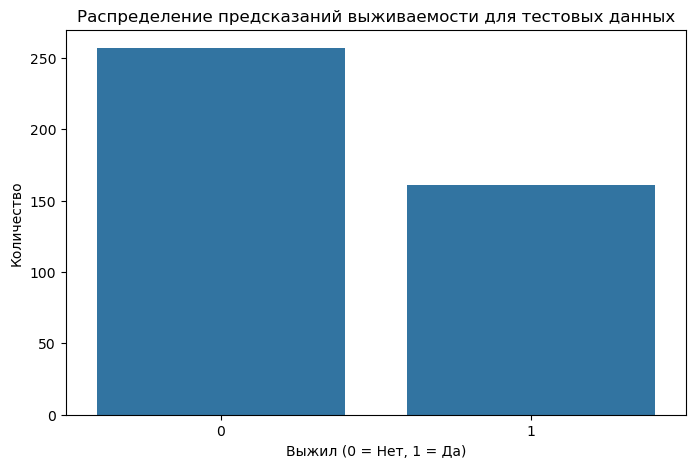

Статистика:
Всего пассажиров: 418
Выжило: 161
Погибло: 257
Процент выживших: 38.52%


In [17]:
# Шаг 16: перепроверка
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=output)
plt.title('Распределение предсказаний выживаемости для тестовых данных')
plt.xlabel('Выжил (0 = Нет, 1 = Да)')
plt.ylabel('Количество')
plt.show()

print("Статистика:")
print(f"Всего пассажиров: {len(predictions)}")
print(f"Выжило: {sum(predictions)}")
print(f"Погибло: {len(predictions) - sum(predictions)}")
print(f"Процент выживших: {(sum(predictions)/len(predictions))*100:.2f}%")